# CRISP-DM Step 2.1 - Dataset Analysis
## Breast Cancer Wisconsin Diagnostic Dataset (WDBC)

This notebook performs the **Dataset Analysis** stage of a CRISP-DM project using the Breast Cancer Wisconsin Diagnostic Dataset (WDBC).

The purpose of this notebook is not to train a model yet. Instead, the goal is to understand the dataset professionally before the next stage, where a **Gaussian Naive Bayes classifier** will be trained.

The analysis follows these questions:

1. What data do we have?
2. Is the dataset clean enough for modeling?
3. What do the numerical variables tell us?
4. Is the target variable balanced?
5. How are predictor variables distributed?
6. Which variables are correlated or redundant?
7. Which variables appear useful for predicting diagnosis?
8. Which subset of variables should be kept for Naive Bayes?
9. What preprocessing decisions are needed before modeling?

The notebook is intentionally written as a readable analysis report so that another student can study both the code and the reasoning.


## 0. Import Libraries and Define Helper Functions

We start by importing the libraries used in the exploratory data analysis.

- `pandas` is used for tabular data handling.
- `numpy` is used for numerical operations.
- `matplotlib` and `seaborn` are used for visual analysis.
- `Path` helps create operating-system-independent file paths.

The helper functions below keep the notebook organized and avoid repeating plotting code.


In [1]:
# Data manipulation and numerical computation
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure a clean and readable visual style for all plots in the notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Project paths. The notebook lives in /notebooks, while the raw data lives in /data.
# Make the path work whether the notebook is run from the project root or from /notebooks.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data" / "breast+cancer+wisconsin+diagnostic"
RAW_DATA_PATH = DATA_DIR / "wdbc.data"
NAMES_PATH = DATA_DIR / "wdbc.names"

# The WDBC dataset has 10 base measurements. For each measurement, the dataset stores:
# - mean value
# - standard error (se)
# - worst value, meaning the mean of the three largest values
BASE_FEATURES = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave_points",
    "symmetry",
    "fractal_dimension",
]

COLUMN_NAMES = ["id", "diagnosis"] + [
    f"{stat}_{feature}"
    for stat in ["mean", "se", "worst"]
    for feature in BASE_FEATURES
]


def load_wdbc_dataset(path: Path) -> pd.DataFrame:
    """Load the WDBC raw .data file and assign meaningful column names."""
    return pd.read_csv(path, header=None, names=COLUMN_NAMES)


def plot_numeric_grid(data: pd.DataFrame, columns: list[str], plot_type: str, title: str) -> None:
    """Plot histograms or boxplots for many numerical columns in a compact grid."""
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for ax, column in zip(axes, columns):
        if plot_type == "hist":
            sns.histplot(data=data, x=column, bins=30, kde=True, ax=ax, color="#2F80ED")
            ax.set_ylabel("Frequency")
        elif plot_type == "box":
            sns.boxplot(data=data, y=column, ax=ax, color="#56CC9D")
            ax.set_ylabel(column)
        else:
            raise ValueError("plot_type must be either 'hist' or 'box'.")

        ax.set_title(column.replace("_", " ").title())
        ax.set_xlabel(column if plot_type == "hist" else "")

    # Hide unused axes when the number of plots does not perfectly fill the grid.
    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=18, y=1.002)
    plt.tight_layout()
    plt.show()


def detect_iqr_outliers(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Count possible outliers in each numerical column using the 1.5 x IQR rule."""
    records = []

    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (data[column] < lower_bound) | (data[column] > upper_bound)

        records.append(
            {
                "feature": column,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "possible_outliers": int(mask.sum()),
                "outlier_percentage": 100 * mask.mean(),
            }
        )

    return pd.DataFrame(records).sort_values("possible_outliers", ascending=False)


Matplotlib is building the font cache; this may take a moment.


## 1. Dataset Import Inspection

The raw WDBC file does not include a header row, so column names are assigned manually using the official dataset description.

This inspection is important because it confirms that the data was loaded correctly before any modeling decisions are made. If columns are shifted, mislabeled, or read as incorrect data types, all later conclusions would be unreliable.

A CSV copy is **not created** in this notebook because it is not necessary: the raw `.data` file is already cleanly readable with `pandas.read_csv`, and creating an extra file would add duplicate data without improving the analysis.


In [2]:
# Load the dataset from the local raw file.
df = load_wdbc_dataset(RAW_DATA_PATH)

# Predictor columns exclude the patient identifier and the target label.
numeric_features = [column for column in df.columns if column not in ["id", "diagnosis"]]

# Display the first rows to verify that the file was parsed correctly.
df.head()


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The first rows allow us to visually confirm the structure of the dataset. We should see one identifier column, one diagnosis label, and 30 numerical measurements describing tumor cell nuclei.


In [3]:
# Show the number of rows and columns.
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 569
Columns: 32


The dimensions tell us the size of the dataset. WDBC is a relatively small tabular dataset, which means careful feature selection and validation will be important in later modeling stages.


In [4]:
# Show all column names so we can verify that the schema is complete.
df.columns.to_list()


['id',
 'diagnosis',
 'mean_radius',
 'mean_texture',
 'mean_perimeter',
 'mean_area',
 'mean_smoothness',
 'mean_compactness',
 'mean_concavity',
 'mean_concave_points',
 'mean_symmetry',
 'mean_fractal_dimension',
 'se_radius',
 'se_texture',
 'se_perimeter',
 'se_area',
 'se_smoothness',
 'se_compactness',
 'se_concavity',
 'se_concave_points',
 'se_symmetry',
 'se_fractal_dimension',
 'worst_radius',
 'worst_texture',
 'worst_perimeter',
 'worst_area',
 'worst_smoothness',
 'worst_compactness',
 'worst_concavity',
 'worst_concave_points',
 'worst_symmetry',
 'worst_fractal_dimension']

The column names show the dataset design. Each base measurement appears three times: as a mean value, a standard error value, and a worst value. This repeated structure is useful, but it may also create redundancy because related measurements can be strongly correlated.


In [5]:
# Show data types for every column.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  se_radius                569 non-null    float64
 13  se_texture               569 non-null    float64
 14  se_perimeter             569 non-null

The data types confirm whether variables are numeric or categorical. For Gaussian Naive Bayes, predictor variables should be numerical. The diagnosis column is categorical and will later need to be encoded as numbers before training.


## 2. Dataset Quality Inspection

Before training any Machine Learning model, data quality must be checked. Missing values, duplicated records, invalid labels, or impossible numerical values can distort probability estimates and lead to unreliable predictions.


In [6]:
# Count missing values per column.
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


Series([], dtype: int64)

Missing values matter because most ML algorithms cannot directly learn from absent numerical values. For Gaussian Naive Bayes, missing values would need to be imputed or removed before training. Here, the output should confirm that no missing values are present.


In [7]:
# Count duplicated full rows.
duplicate_count = df.duplicated().sum()
print(f"Duplicated rows: {duplicate_count}")

# Check whether the identifier column uniquely identifies each patient/sample.
print(f"Unique IDs: {df['id'].nunique()}")
print(f"Total rows: {len(df)}")


Duplicated rows: 0
Unique IDs: 569
Total rows: 569


Duplicated rows can cause the model to overrepresent repeated samples, which may make performance appear better than it truly is. Unique IDs are also checked because repeated identifiers could indicate duplicate or inconsistent records.


In [8]:
# Inspect valid class labels and their counts.
df["diagnosis"].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

The diagnosis column should contain only two valid labels:

- `B`: benign
- `M`: malignant

Invalid class labels would create ambiguity in the target variable and would need to be corrected before modeling.


In [9]:
# Check for unexpected class labels.
valid_labels = {"B", "M"}
observed_labels = set(df["diagnosis"].unique())
invalid_labels = observed_labels - valid_labels

print(f"Observed labels: {sorted(observed_labels)}")
print(f"Invalid labels: {sorted(invalid_labels)}")


Observed labels: ['B', 'M']
Invalid labels: []


In [10]:
# Check ranges and unique counts for numerical variables.
# Negative values would be suspicious because these measurements represent physical quantities.
quality_summary = pd.DataFrame(
    {
        "dtype": df[numeric_features].dtypes,
        "unique_values": df[numeric_features].nunique(),
        "minimum": df[numeric_features].min(),
        "maximum": df[numeric_features].max(),
        "has_negative_values": (df[numeric_features] < 0).any(),
    }
)

quality_summary


,dtype,unique_values,minimum,maximum,has_negative_values
mean_radius,float64,456,6.981000,28.11000,False
mean_texture,float64,479,9.710000,39.28000,False
mean_perimeter,float64,522,43.790000,188.50000,False
mean_area,float64,539,143.500000,2501.00000,False
mean_smoothness,float64,474,0.052630,0.16340,False
mean_compactness,float64,537,0.019380,0.34540,False
mean_concavity,float64,537,0.000000,0.42680,False
mean_concave_points,float64,542,0.000000,0.20120,False
mean_symmetry,float64,432,0.106000,0.30400,False
mean_fractal_dimension,float64,499,0.049960,0.09744,False


Unique-value counts and numerical ranges help identify invalid values. For these tumor measurements, negative values would not be meaningful. Very low unique counts could indicate a constant or near-constant variable that contributes little information to a model.


## 3. Descriptive Statistics

Descriptive statistics summarize each numerical variable.

Important measures include:

- **Mean**: average value; sensitive to extreme values.
- **Median**: middle value; more robust to outliers.
- **Standard deviation**: typical amount of variation around the mean.
- **Minimum and maximum**: observed range.
- **Quartiles**: values at 25%, 50%, and 75% of the distribution.

These statistics help us understand scale, spread, and possible outliers before modeling.


In [11]:
# Transpose descriptive statistics so each feature is one row.
descriptive_stats = df[numeric_features].describe().T

# Add the median explicitly to make the comparison with the mean clearer.
descriptive_stats["median"] = df[numeric_features].median()

# Reorder columns for readability.
descriptive_stats = descriptive_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]

descriptive_stats


,count,mean,median,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,13.370000,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,18.840000,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,86.240000,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,551.100000,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.095870,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.092630,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.061540,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.033500,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.179200,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.061540,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


The descriptive statistics show that variables are measured on very different scales. For example, area-related variables have much larger numerical values and variance than smoothness or fractal-dimension variables. This is expected because the features represent different physical measurements.


In [12]:
# Identify variables with the highest and lowest variance.
variance_summary = df[numeric_features].var().sort_values(ascending=False).to_frame("variance")

print("Variables with highest variance:")
display(variance_summary.head(10))

print("Variables with lowest variance:")
display(variance_summary.tail(10))


Variables with highest variance:


,variance
worst_area,324167.385102
mean_area,123843.554318
se_area,2069.431583
worst_perimeter,1129.130847
mean_perimeter,590.440480
worst_texture,37.776483
worst_radius,23.360224
mean_texture,18.498909
mean_radius,12.418920
se_perimeter,4.087896


Variables with lowest variance:


,variance
mean_symmetry,0.000752
worst_smoothness,0.000521
worst_fractal_dimension,0.000326
se_compactness,0.000321
mean_smoothness,0.000198
se_symmetry,0.000068
mean_fractal_dimension,0.000050
se_concave_points,0.000038
se_smoothness,0.000009
se_fractal_dimension,0.000007


High variance variables are often area, perimeter, and radius measures because they are measured on larger scales. Low variance variables are often smoothness, symmetry, and fractal-dimension measures because their numerical ranges are naturally small.

Variance alone does not determine predictive usefulness. A variable can have low variance but still separate classes well if the class distributions differ consistently.


In [13]:
# Detect possible outliers using the common 1.5 x IQR rule.
outlier_summary = detect_iqr_outliers(df, numeric_features)
outlier_summary.head(15)


,feature,q1,q3,iqr,lower_bound,upper_bound,possible_outliers,outlier_percentage
13,se_area,17.850000,45.190000,27.340000,-23.160000,86.200000,65,11.423550
10,se_radius,0.232400,0.478900,0.246500,-0.137350,0.848650,38,6.678383
12,se_perimeter,1.606000,3.357000,1.751000,-1.020500,5.983500,38,6.678383
23,worst_area,515.300000,1084.000000,568.700000,-337.750000,1937.050000,35,6.151142
14,se_smoothness,0.005169,0.008146,0.002977,0.000703,0.012612,30,5.272408
15,se_compactness,0.013080,0.032450,0.019370,-0.015975,0.061505,28,4.920914
19,se_fractal_dimension,0.002248,0.004558,0.002310,-0.001217,0.008023,28,4.920914
18,se_symmetry,0.015160,0.023480,0.008320,0.002680,0.035960,27,4.745167
3,mean_area,420.300000,782.700000,362.400000,-123.300000,1326.300000,25,4.393673
29,worst_fractal_dimension,0.071460,0.092080,0.020620,0.040530,0.123010,24,4.217926


The IQR rule flags possible outliers, not necessarily errors. In medical measurements, extreme values may represent real tumor characteristics. Therefore, outliers should not be automatically removed. For the next stage, they should be handled carefully because Gaussian Naive Bayes estimates means and variances, which can be influenced by extreme values.


## 4. Target Variable Analysis

The target variable is `diagnosis`. We need to understand how many benign and malignant examples are available because class imbalance can affect model learning and evaluation.


In [14]:
# Count and percentage of each diagnosis class.
target_counts = df["diagnosis"].value_counts().rename_axis("diagnosis").reset_index(name="count")
target_counts["percentage"] = 100 * target_counts["count"] / len(df)
target_counts


,diagnosis,count,percentage
0,B,357,62.741652
1,M,212,37.258348


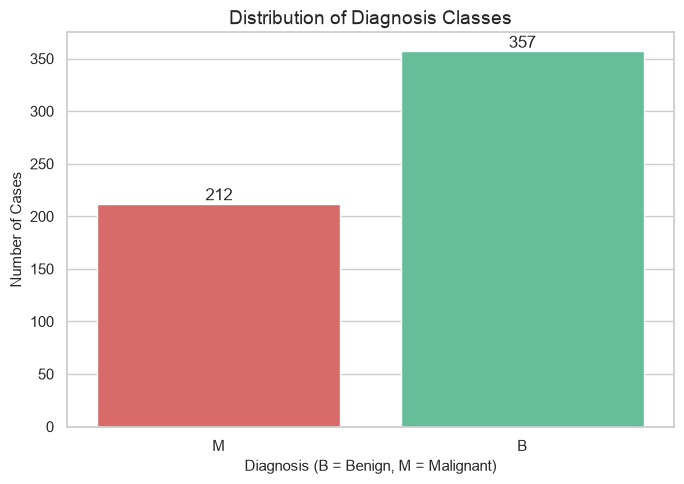

In [15]:
# Visualize the target distribution.
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette={"B": "#56CC9D", "M": "#EB5757"}, legend=False)
ax.set_title("Distribution of Diagnosis Classes")
ax.set_xlabel("Diagnosis (B = Benign, M = Malignant)")
ax.set_ylabel("Number of Cases")

# Add count labels above the bars.
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


The dataset contains more benign cases than malignant cases. The imbalance is noticeable but not extreme: both classes have enough samples for analysis.

Class imbalance matters because a classifier can appear accurate by favoring the majority class. In the next modeling stage, accuracy should therefore be interpreted alongside metrics such as recall, precision, F1-score, and the confusion matrix, especially because missing malignant cases has a high practical cost.


## 5. Distribution Analysis

Distribution analysis shows how predictor variables behave individually. This is especially important for Gaussian Naive Bayes because it models each numerical feature within each class using a Gaussian distribution.

We inspect:

- histograms with KDE curves for distribution shape;
- boxplots for spread and possible outliers;
- skewness values to quantify asymmetry.


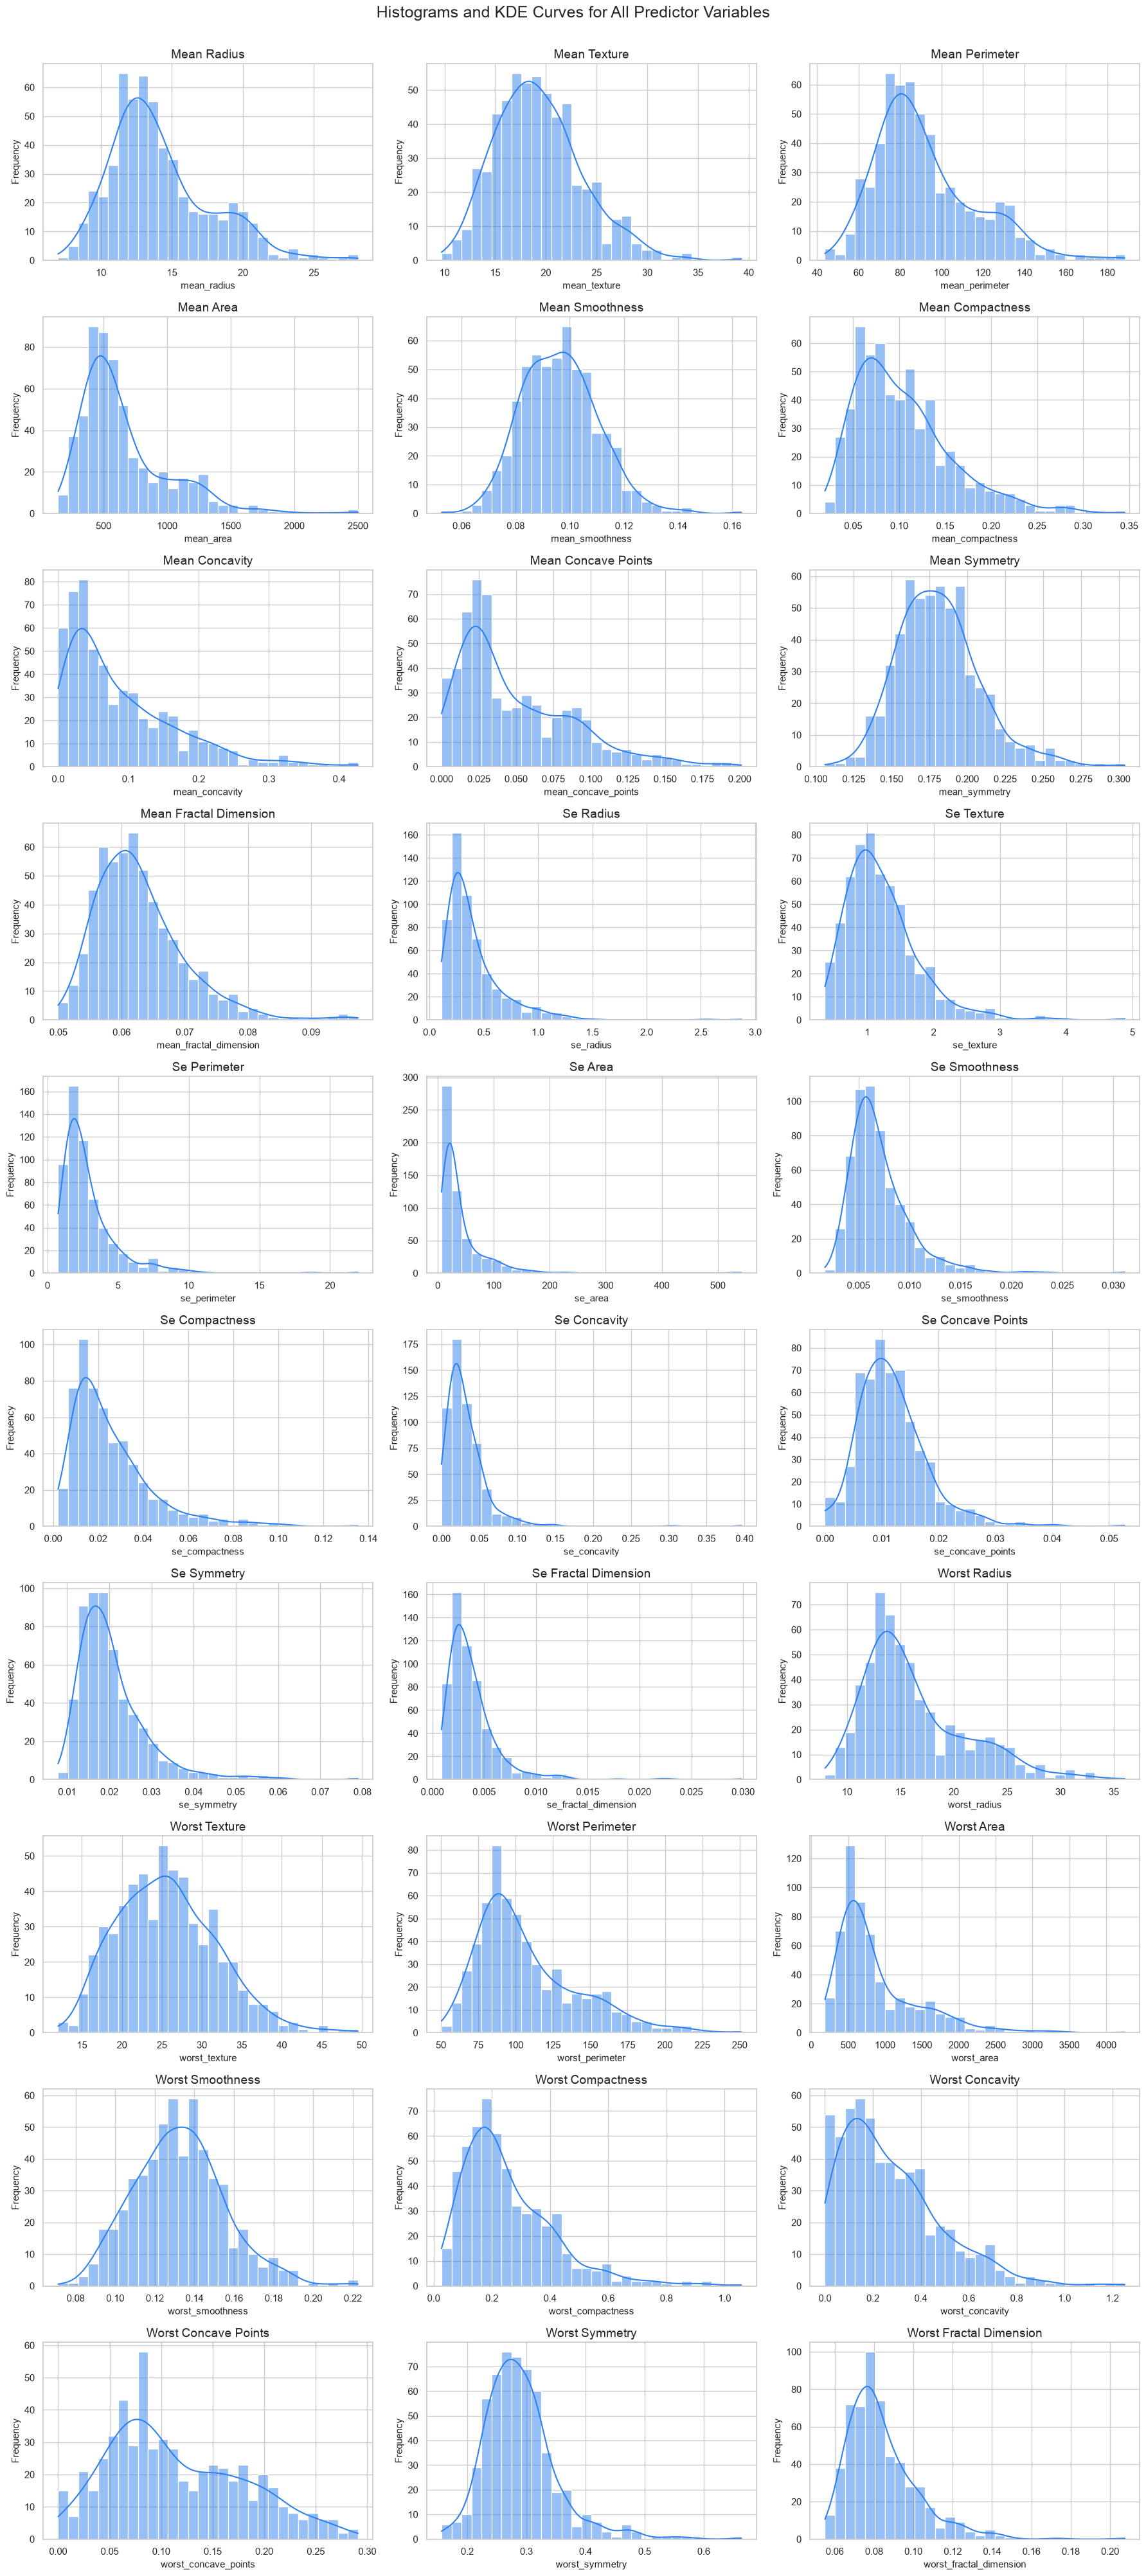

In [16]:
# Histograms with KDE curves for all predictor variables.
plot_numeric_grid(
    data=df,
    columns=numeric_features,
    plot_type="hist",
    title="Histograms and KDE Curves for All Predictor Variables",
)


The histograms show that many variables are right-skewed, especially standard-error variables and area-related variables. Right skew means most observations are concentrated at lower values, with a smaller number of large values.

This matters for Gaussian Naive Bayes because the Gaussian assumption is easier to satisfy when variables are roughly bell-shaped within each class. However, Gaussian Naive Bayes can still work well in practice even when the assumption is imperfect.


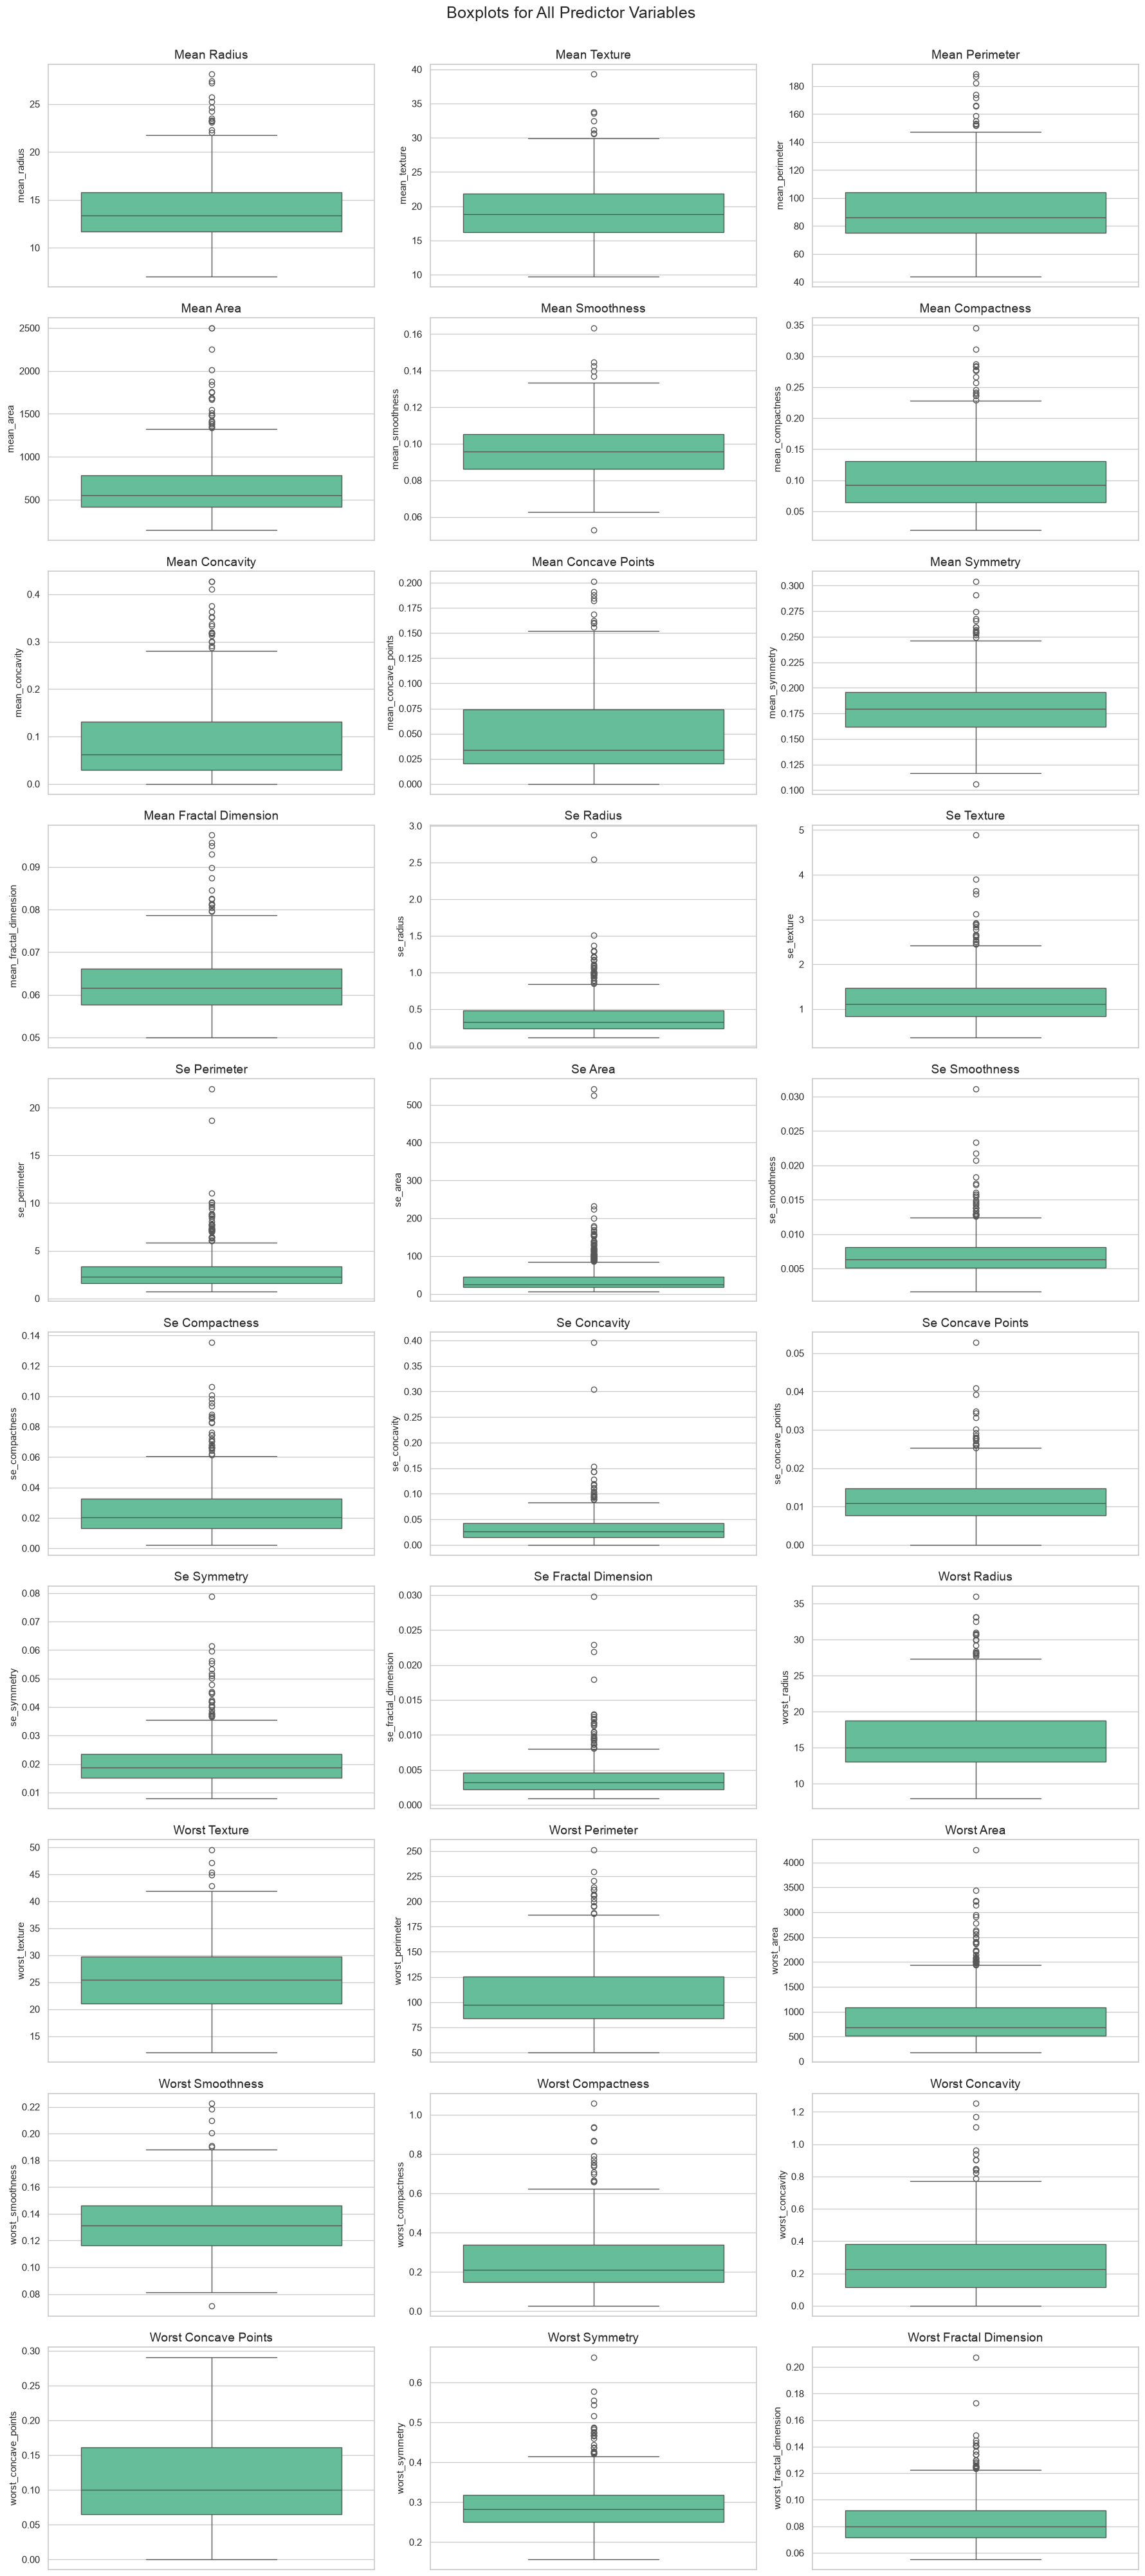

In [17]:
# Boxplots for all predictor variables.
plot_numeric_grid(
    data=df,
    columns=numeric_features,
    plot_type="box",
    title="Boxplots for All Predictor Variables",
)


The boxplots make extreme observations easier to see. Many features contain possible high-end outliers. These should be interpreted as possible genuine tumor measurements rather than automatically treated as mistakes.

Because this is a medical dataset, removing extreme values without domain justification could remove clinically important malignant cases.


In [18]:
# Quantify distribution asymmetry using skewness.
skewness_summary = df[numeric_features].skew().sort_values(key=lambda values: values.abs(), ascending=False)
skewness_summary.to_frame("skewness")


,skewness
se_area,5.447186
se_concavity,5.110463
se_fractal_dimension,3.923969
se_perimeter,3.443615
se_radius,3.088612
se_smoothness,2.314450
se_symmetry,2.195133
se_compactness,1.902221
worst_area,1.859373
worst_fractal_dimension,1.662579


Skewness confirms the visual pattern from the histograms. Positive skewness means the right tail is longer. The most skewed variables are mostly standard-error measurements, indicating that most tumors have small local variation but a few cases have much larger variation.


## 6. Correlation Analysis

Correlation analysis helps identify variables that move together. This is important because the WDBC dataset contains related measurements such as radius, perimeter, and area. These variables often describe similar tumor-size information.

Naive Bayes assumes that features are conditionally independent given the class. Highly correlated predictors violate this assumption and can cause the model to count similar evidence multiple times.


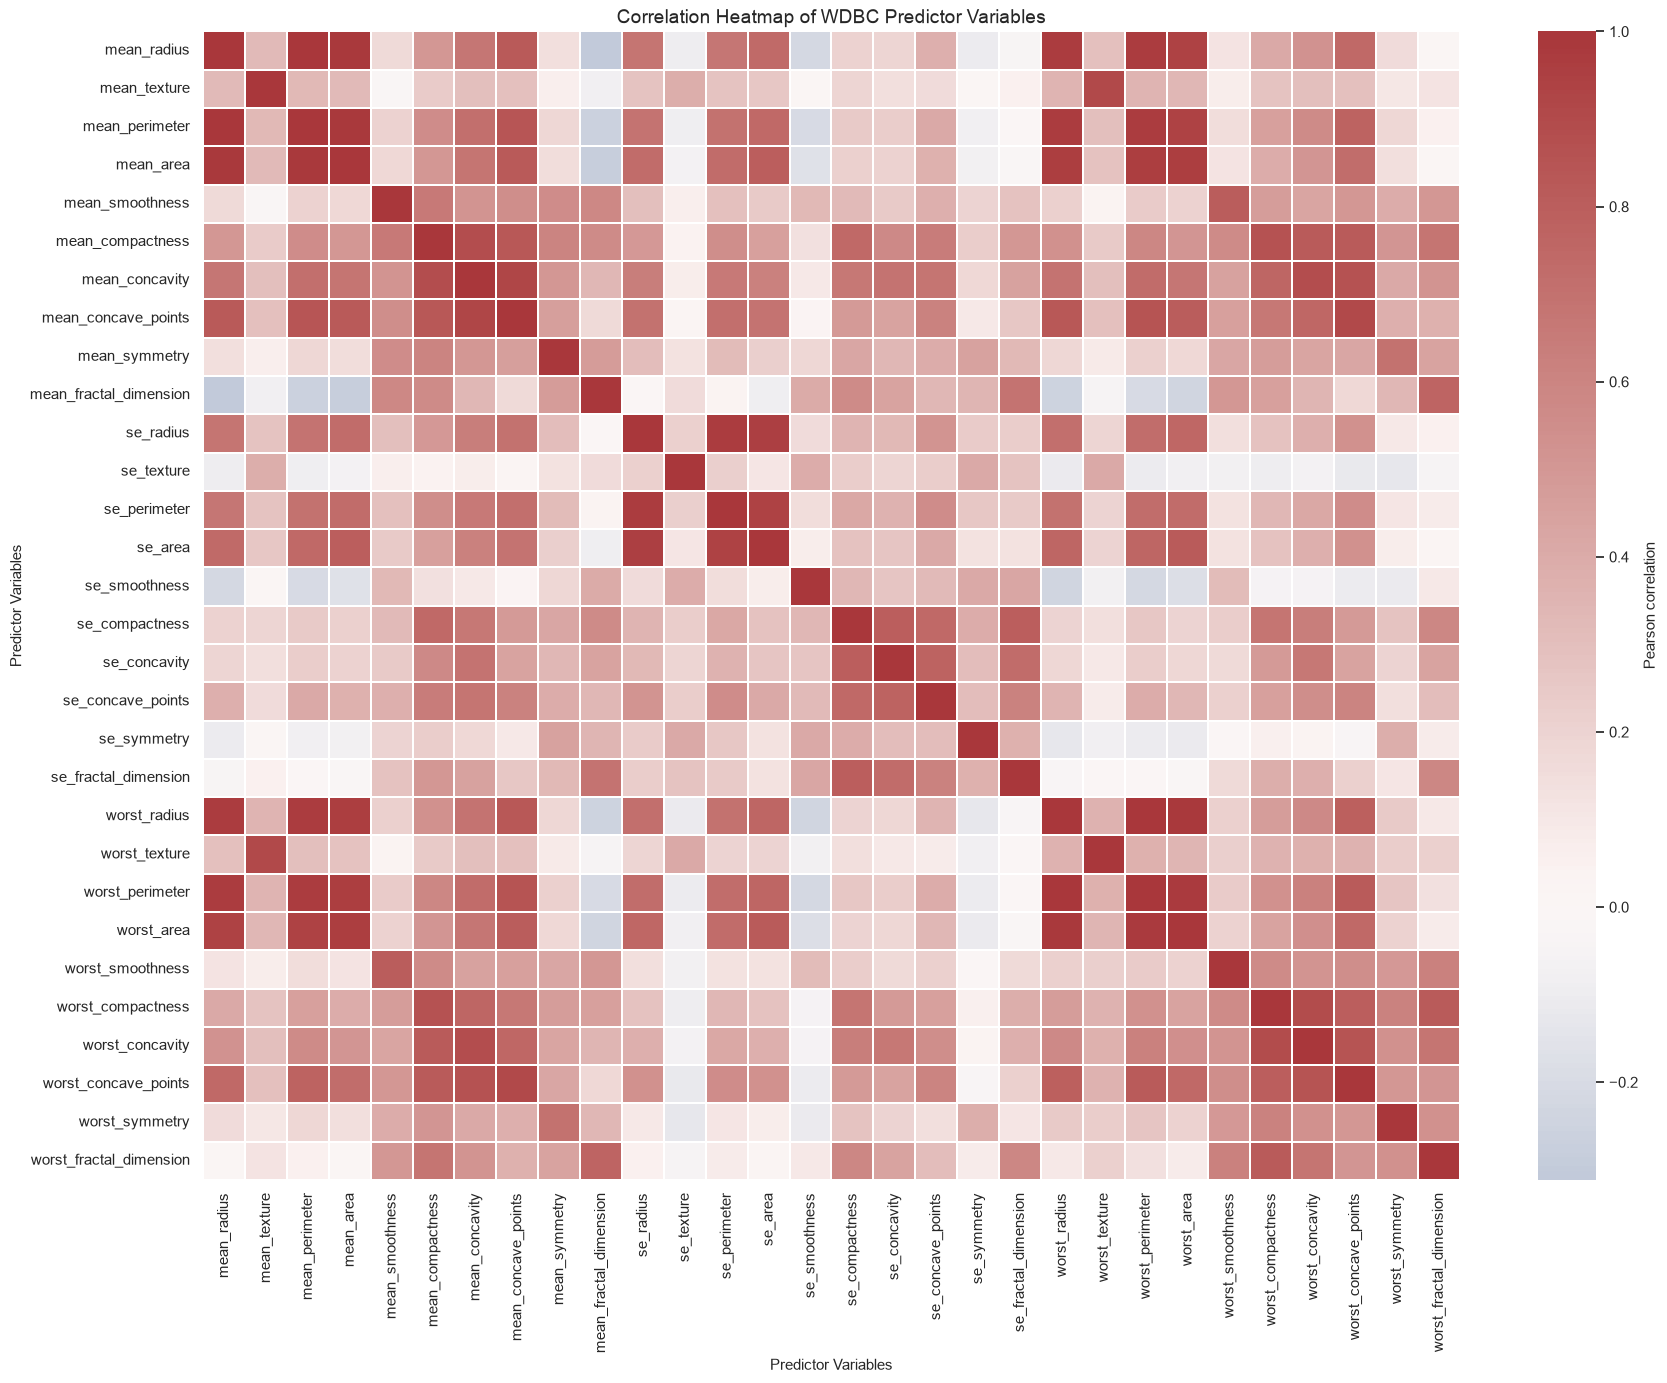

In [19]:
# Compute the Pearson correlation matrix for numerical predictors.
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Heatmap of WDBC Predictor Variables")
plt.xlabel("Predictor Variables")
plt.ylabel("Predictor Variables")
plt.tight_layout()
plt.show()


In [20]:
# Identify highly correlated feature pairs.
high_correlation_pairs = []

for i, feature_a in enumerate(numeric_features):
    for feature_b in numeric_features[i + 1:]:
        correlation_value = correlation_matrix.loc[feature_a, feature_b]
        if abs(correlation_value) >= 0.90:
            high_correlation_pairs.append(
                {
                    "feature_1": feature_a,
                    "feature_2": feature_b,
                    "correlation": correlation_value,
                    "absolute_correlation": abs(correlation_value),
                }
            )

high_correlation_pairs = (
    pd.DataFrame(high_correlation_pairs)
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

high_correlation_pairs


,feature_1,feature_2,correlation,absolute_correlation
0,mean_radius,mean_perimeter,0.997855,0.997855
1,worst_radius,worst_perimeter,0.993708,0.993708
2,mean_radius,mean_area,0.987357,0.987357
3,mean_perimeter,mean_area,0.986507,0.986507
4,worst_radius,worst_area,0.984015,0.984015
5,worst_perimeter,worst_area,0.977578,0.977578
6,se_radius,se_perimeter,0.972794,0.972794
7,mean_perimeter,worst_perimeter,0.970387,0.970387
8,mean_radius,worst_radius,0.969539,0.969539
9,mean_perimeter,worst_radius,0.969476,0.969476


The strongest correlations are mainly among radius, perimeter, and area features. This makes sense because all three describe tumor size. Concavity and concave-points measurements are also strongly related.

For Naive Bayes, this redundancy matters. If several highly correlated variables are kept, the model may overweight one biological concept, such as tumor size, because the same information appears multiple times.


In [21]:
# Identify weakly correlated feature pairs.
weak_correlation_pairs = []

for i, feature_a in enumerate(numeric_features):
    for feature_b in numeric_features[i + 1:]:
        correlation_value = correlation_matrix.loc[feature_a, feature_b]
        if abs(correlation_value) <= 0.10:
            weak_correlation_pairs.append(
                {
                    "feature_1": feature_a,
                    "feature_2": feature_b,
                    "correlation": correlation_value,
                    "absolute_correlation": abs(correlation_value),
                }
            )

weak_correlation_pairs = (
    pd.DataFrame(weak_correlation_pairs)
    .sort_values("absolute_correlation", ascending=True)
    .reset_index(drop=True)
)

weak_correlation_pairs.head(15)


,feature_1,feature_2,correlation,absolute_correlation
0,mean_fractal_dimension,se_radius,0.000111,0.000111
1,se_fractal_dimension,worst_perimeter,-0.001000,0.001000
2,se_fractal_dimension,worst_texture,-0.003195,0.003195
3,mean_area,worst_fractal_dimension,0.003738,0.003738
4,mean_perimeter,se_fractal_dimension,-0.005523,0.005523
5,mean_texture,se_smoothness,0.006614,0.006614
6,mean_radius,worst_fractal_dimension,0.007066,0.007066
7,mean_texture,se_symmetry,0.009127,0.009127
8,se_symmetry,worst_smoothness,-0.012662,0.012662
9,se_area,worst_fractal_dimension,0.017539,0.017539


Weak correlations indicate pairs of variables that capture more independent information. Such variables can be useful for Naive Bayes because they reduce redundant evidence. However, weak correlation alone is not enough; a selected feature should also show useful separation between benign and malignant tumors.


## 7. Relationship with the Target

To identify variables that may be useful for prediction, we compare each feature with the diagnosis label.

The diagnosis is encoded only for analysis:

- `B = 0`
- `M = 1`

A positive correlation means higher feature values are associated with malignant tumors.


In [22]:
# Create an encoded version of the target for correlation analysis.
df_analysis = df.copy()
df_analysis["diagnosis_encoded"] = df_analysis["diagnosis"].map({"B": 0, "M": 1})

# Compute correlation between each feature and the encoded target.
target_correlation = (
    df_analysis[numeric_features + ["diagnosis_encoded"]]
    .corr()["diagnosis_encoded"]
    .drop("diagnosis_encoded")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

target_correlation.to_frame("correlation_with_malignant_class")


,correlation_with_malignant_class
worst_concave_points,0.793566
worst_perimeter,0.782914
mean_concave_points,0.776614
worst_radius,0.776454
mean_perimeter,0.742636
worst_area,0.733825
mean_radius,0.730029
mean_area,0.708984
mean_concavity,0.696360
worst_concavity,0.659610


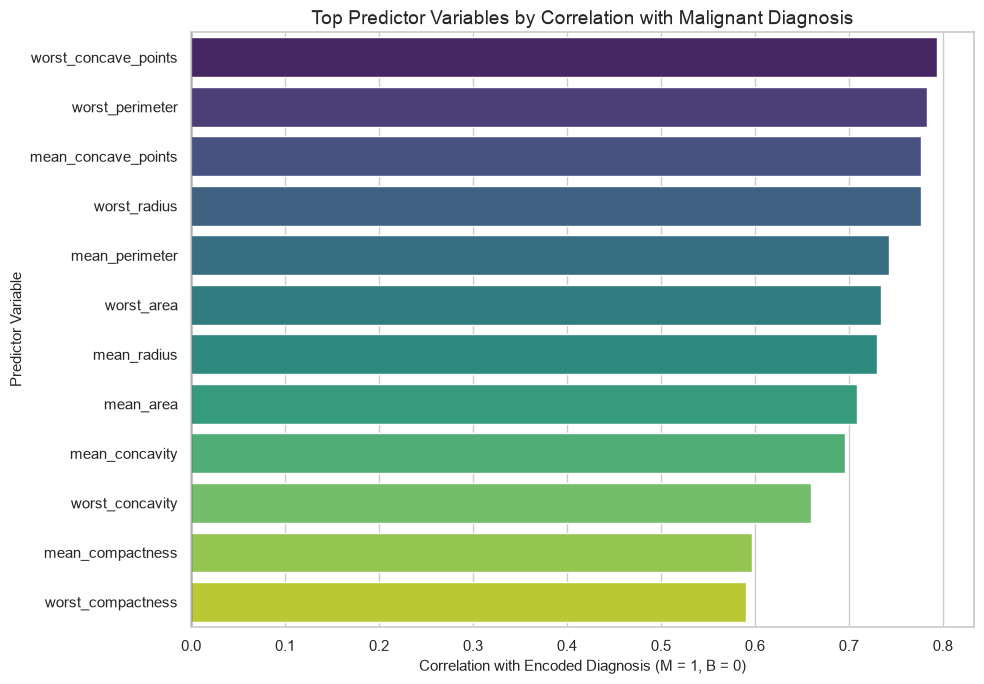

In [23]:
# Visualize the strongest absolute correlations with the target.
top_target_features = target_correlation.abs().head(12).index

plt.figure(figsize=(10, 7))
sns.barplot(
    x=target_correlation.loc[top_target_features].values,
    y=top_target_features,
    hue=top_target_features,
    palette="viridis",
    legend=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Predictor Variables by Correlation with Malignant Diagnosis")
plt.xlabel("Correlation with Encoded Diagnosis (M = 1, B = 0)")
plt.ylabel("Predictor Variable")
plt.tight_layout()
plt.show()


The variables most associated with malignant diagnosis include worst concave points, worst perimeter, mean concave points, worst radius, mean perimeter, worst area, and mean radius.

These variables describe tumor boundary irregularity and tumor size. Malignant tumors tend to have larger and more irregular nuclei, so this pattern is consistent with the medical meaning of the features.


In [24]:
# Compare class means and standardized separation using Cohen's d.
class_separation_records = []
class_counts = df["diagnosis"].value_counts()

for feature in numeric_features:
    benign_values = df.loc[df["diagnosis"] == "B", feature]
    malignant_values = df.loc[df["diagnosis"] == "M", feature]

    pooled_std = np.sqrt(
        ((len(benign_values) - 1) * benign_values.std() ** 2 + (len(malignant_values) - 1) * malignant_values.std() ** 2)
        / (len(benign_values) + len(malignant_values) - 2)
    )

    cohens_d = (malignant_values.mean() - benign_values.mean()) / pooled_std

    class_separation_records.append(
        {
            "feature": feature,
            "benign_mean": benign_values.mean(),
            "malignant_mean": malignant_values.mean(),
            "cohens_d": cohens_d,
            "absolute_cohens_d": abs(cohens_d),
            "target_correlation": target_correlation.loc[feature],
        }
    )

class_separation = (
    pd.DataFrame(class_separation_records)
    .sort_values("absolute_cohens_d", ascending=False)
    .reset_index(drop=True)
)

class_separation.head(15)


,feature,benign_mean,malignant_mean,cohens_d,absolute_cohens_d,target_correlation
0,worst_concave_points,0.074444,0.182237,2.692647,2.692647,0.793566
1,worst_perimeter,87.005938,141.370330,2.598237,2.598237,0.782914
2,mean_concave_points,0.025717,0.087990,2.545225,2.545225,0.776614
3,worst_radius,13.379801,21.134811,2.543903,2.543903,0.776454
4,mean_perimeter,78.075406,115.365377,2.289516,2.289516,0.742636
5,worst_area,558.899440,1422.286321,2.230242,2.230242,0.733825
6,mean_radius,12.146524,17.462830,2.205463,2.205463,0.730029
7,mean_area,462.790196,978.376415,2.075651,2.075651,0.708984
8,mean_concavity,0.046058,0.160775,2.003275,2.003275,0.696360
9,worst_concavity,0.166238,0.450606,1.811931,1.811931,0.659610


Cohen's d measures standardized difference between benign and malignant means. Larger absolute values indicate stronger class separation.

The same variables that correlate strongly with the target also show large differences in group means, which strengthens the evidence that they are useful predictors.


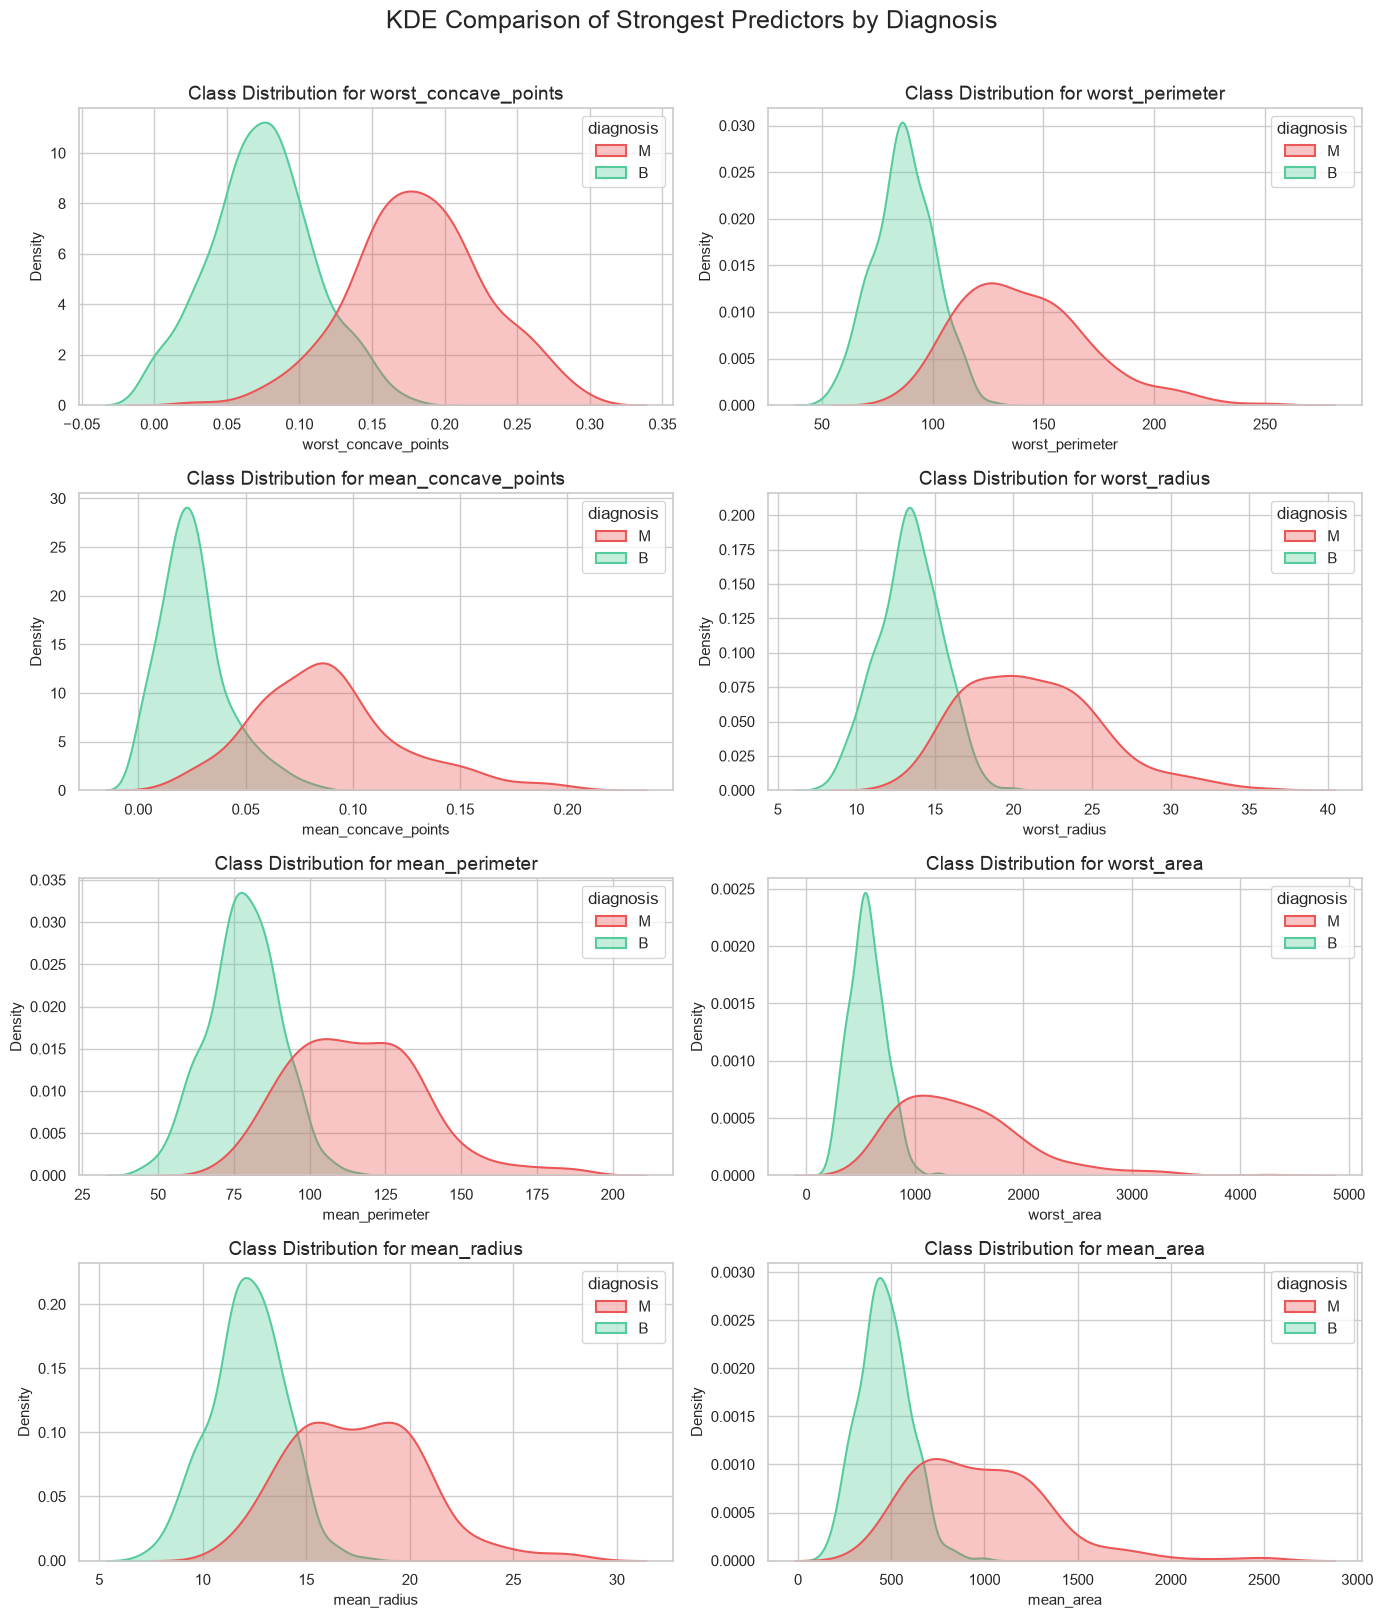

In [25]:
# KDE plots for the features with strongest class separation.
strongest_separation_features = class_separation.head(8)["feature"].to_list()

n_cols = 2
n_rows = int(np.ceil(len(strongest_separation_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, strongest_separation_features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="diagnosis",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5,
        palette={"B": "#56CC9D", "M": "#EB5757"},
        ax=ax,
    )
    ax.set_title(f"Class Distribution for {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

for ax in axes[len(strongest_separation_features):]:
    ax.set_visible(False)

fig.suptitle("KDE Comparison of Strongest Predictors by Diagnosis", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


The KDE plots compare benign and malignant distributions directly. Useful predictors show distributions that are shifted apart, with malignant cases generally having higher values.

Worst concave points, size-related features, and concavity-related features show clear separation. Variables with strong overlap may still contribute information, but they are less powerful individually.


## 8. Feature Selection for Gaussian Naive Bayes

This is the most important section of the EDA because the next project step will train a Gaussian Naive Bayes classifier.

Feature selection is based on four principles:

1. **Predictive power**: keep variables that separate benign and malignant tumors.
2. **Redundancy control**: avoid keeping many variables that measure the same concept.
3. **Naive Bayes suitability**: reduce strong feature correlation because Naive Bayes assumes conditional independence.
4. **Interpretability**: prefer variables that are medically and geometrically meaningful.

The selection is not random. It is based on target correlation, grouped statistics, distribution plots, and feature-to-feature correlation.


In [26]:
# A simple evidence table for feature selection.
selection_evidence = class_separation.merge(
    variance_summary.reset_index().rename(columns={"index": "feature"}),
    on="feature",
    how="left",
)

selection_evidence["absolute_target_correlation"] = selection_evidence["target_correlation"].abs()
selection_evidence[
    [
        "feature",
        "benign_mean",
        "malignant_mean",
        "cohens_d",
        "target_correlation",
        "absolute_target_correlation",
        "variance",
    ]
].head(20)


,feature,benign_mean,malignant_mean,cohens_d,target_correlation,absolute_target_correlation,variance
0,worst_concave_points,0.074444,0.182237,2.692647,0.793566,0.793566,0.004321
1,worst_perimeter,87.005938,141.370330,2.598237,0.782914,0.782914,1129.130847
2,mean_concave_points,0.025717,0.087990,2.545225,0.776614,0.776614,0.001506
3,worst_radius,13.379801,21.134811,2.543903,0.776454,0.776454,23.360224
4,mean_perimeter,78.075406,115.365377,2.289516,0.742636,0.742636,590.440480
5,worst_area,558.899440,1422.286321,2.230242,0.733825,0.733825,324167.385102
6,mean_radius,12.146524,17.462830,2.205463,0.730029,0.730029,12.418920
7,mean_area,462.790196,978.376415,2.075651,0.708984,0.708984,123843.554318
8,mean_concavity,0.046058,0.160775,2.003275,0.696360,0.696360,0.006355
9,worst_concavity,0.166238,0.450606,1.811931,0.659610,0.659610,0.043524


In [27]:
# Final selected features for the next modeling stage.
# The list keeps strong predictors while limiting severe redundancy among radius/perimeter/area
# and among related concavity/concave-points measurements.
selected_features = [
    "worst_concave_points",
    "worst_perimeter",
    "mean_compactness",
    "se_radius",
    "worst_texture",
    "worst_smoothness",
    "worst_symmetry",
    "se_concave_points",
]

selected_features


['worst_concave_points',
 'worst_perimeter',
 'mean_compactness',
 'se_radius',
 'worst_texture',
 'worst_smoothness',
 'worst_symmetry',
 'se_concave_points']

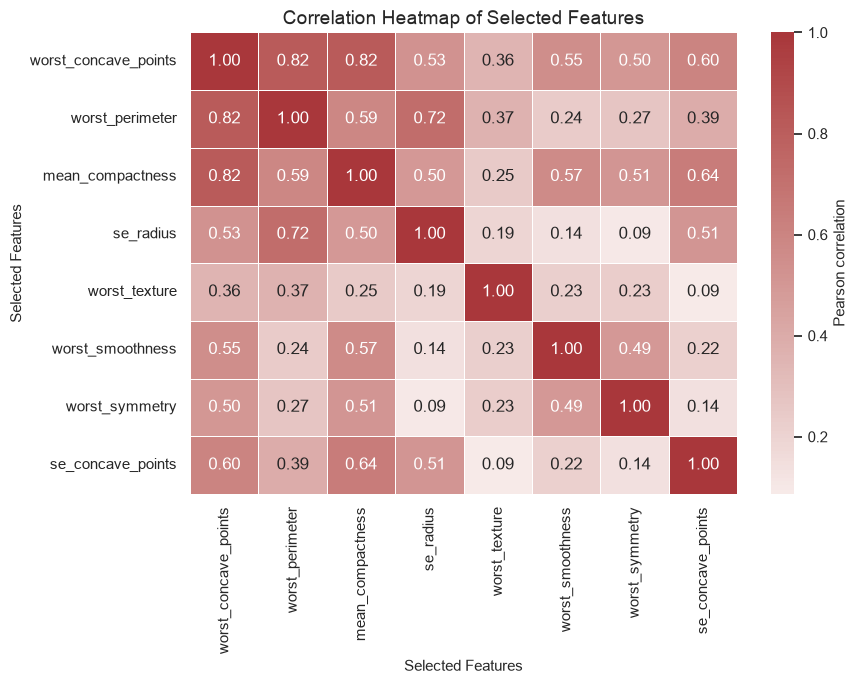

,worst_concave_points,worst_perimeter,mean_compactness,se_radius,worst_texture,worst_smoothness,worst_symmetry,se_concave_points
worst_concave_points,1.000000,0.816322,0.815573,0.531062,0.359755,0.547691,0.502528,0.602450
worst_perimeter,0.816322,1.000000,0.590210,0.719684,0.365098,0.236775,0.269493,0.394999
mean_compactness,0.815573,0.590210,1.000000,0.497473,0.248133,0.565541,0.510223,0.642262
se_radius,0.531062,0.719684,0.497473,1.000000,0.194799,0.141919,0.094543,0.513346
worst_texture,0.359755,0.365098,0.248133,0.194799,1.000000,0.225429,0.233027,0.086741
worst_smoothness,0.547691,0.236775,0.565541,0.141919,0.225429,1.000000,0.493838,0.215351
worst_symmetry,0.502528,0.269493,0.510223,0.094543,0.233027,0.493838,1.000000,0.143116
se_concave_points,0.602450,0.394999,0.642262,0.513346,0.086741,0.215351,0.143116,1.000000


In [28]:
# Inspect correlations among the selected features to confirm reduced redundancy.
selected_correlation = df[selected_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    selected_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Heatmap of Selected Features")
plt.xlabel("Selected Features")
plt.ylabel("Selected Features")
plt.tight_layout()
plt.show()

selected_correlation.abs()


### Why These Features Were Kept

The selected feature subset is:

1. `worst_concave_points`
2. `worst_perimeter`
3. `mean_compactness`
4. `se_radius`
5. `worst_texture`
6. `worst_smoothness`
7. `worst_symmetry`
8. `se_concave_points`

All selected predictor variables are **quantitative continuous variables**. They are quantitative because each one is represented by a numerical measurement computed from the digitized image of a fine needle aspirate. They are continuous because measurements such as perimeter, compactness, texture, smoothness, symmetry, and concave points can vary over a range of real-number values rather than belonging to a fixed set of categories.

This distinction matters for the next modeling stage. Gaussian Naive Bayes is designed for numerical continuous predictors because it estimates a mean and variance for each feature within each class. Therefore, these selected variables are suitable inputs for Gaussian Naive Bayes. By contrast, the target variable `diagnosis` is **qualitative nominal** before encoding because its values are class labels (`B` for benign and `M` for malignant), not numerical measurements. It is encoded only so that the classifier can process the labels.

**`worst_concave_points`** was kept because it is the strongest predictor in the EDA. It has the highest correlation with malignant diagnosis and the largest class separation. It captures boundary irregularity, which is highly relevant for distinguishing malignant tumors.

**`worst_perimeter`** was kept as a representative size-related variable. Radius, perimeter, and area are highly correlated, so keeping all of them would add redundant size information. Worst perimeter was chosen because it has strong predictive power and represents the largest observed tumor-boundary size.

**`mean_compactness`** was kept because it captures shape complexity through the relationship between perimeter and area. It provides information that is related to but not identical to simple tumor size.

**`se_radius`** was kept because it represents local variability in radius. Standard-error features are often skewed, but this one shows meaningful class separation and adds information about variation rather than only average or worst-case size.

**`worst_texture`** was kept because texture describes gray-scale variation and is less redundant with geometric size variables. It adds a different type of biological information.

**`worst_smoothness`** was kept because it captures local variation in radius lengths. Although its target correlation is moderate, it adds shape-surface information that is not the same as perimeter or concavity.

**`worst_symmetry`** was kept because symmetry provides interpretable shape information and has moderate separation between benign and malignant cases.

**`se_concave_points`** was kept because it adds information about variability in concave portions. It is related to concavity but focuses on standard error, making it different from the strongest worst-value feature.


### Why Other Features Were Discarded

Many discarded variables are not useless. They were removed mainly because they are redundant with stronger selected variables.

- `mean_radius`, `worst_radius`, `mean_perimeter`, `mean_area`, and `worst_area` were discarded because they are highly correlated with `worst_perimeter`. Keeping all of them would repeatedly represent tumor size.
- `mean_concave_points`, `mean_concavity`, and `worst_concavity` were discarded because they are strongly related to `worst_concave_points`, which was the strongest single predictor.
- Several standard-error variables, such as `se_area` and `se_perimeter`, were discarded because they are highly correlated with radius/perimeter/area measurements and are strongly skewed.
- Lower-signal variables such as some fractal-dimension measurements were discarded because they showed weaker target association and less class separation.

This subset aims to preserve useful biological information while reducing unnecessary dependence among predictors, which is especially important for Naive Bayes.


## 9. Preprocessing Discussion

Before training the Gaussian Naive Bayes classifier in step 2.2, the following preprocessing decisions should be applied.


In [29]:
# Create a modeling-ready preview using only the selected features and encoded target.
# This cell does not train a model; it only shows what the next stage can use.
modeling_preview = df[selected_features].copy()
modeling_preview["diagnosis_encoded"] = df["diagnosis"].map({"B": 0, "M": 1})

modeling_preview.head()


,worst_concave_points,worst_perimeter,mean_compactness,se_radius,worst_texture,worst_smoothness,worst_symmetry,se_concave_points,diagnosis_encoded
0,0.2654,184.60,0.27760,1.0950,17.33,0.1622,0.4601,0.01587,1
1,0.1860,158.80,0.07864,0.5435,23.41,0.1238,0.2750,0.01340,1
2,0.2430,152.50,0.15990,0.7456,25.53,0.1444,0.3613,0.02058,1
3,0.2575,98.87,0.28390,0.4956,26.50,0.2098,0.6638,0.01867,1
4,0.1625,152.20,0.13280,0.7572,16.67,0.1374,0.2364,0.01885,1


### Preprocessing Decisions

**Remove identifier column:** `id` should not be used as a predictor. It is an identifier, not a biological measurement. Including it could introduce meaningless patterns.

**Encode target labels:** `diagnosis` should be encoded numerically for modeling: `B = 0` and `M = 1`. This makes the target compatible with scikit-learn classifiers.

**Missing values:** No missing values were found, so imputation is unnecessary.

**Duplicated rows:** No duplicated full rows were found, so duplicate removal is unnecessary.

**Invalid values:** No invalid class labels or negative numerical measurements were found.

**Normalization or standardization:** Gaussian Naive Bayes does not require feature scaling in the same way that distance-based models do, because it estimates a separate mean and variance for each feature by class. Standardization may still be useful for visualization or for comparing coefficients in other models, but it is not required for Gaussian Naive Bayes.

**Outliers:** Possible outliers were detected by the IQR rule, but they should not be removed automatically. They may represent clinically meaningful tumor characteristics. If later evaluation shows instability, robust transformations or careful outlier analysis can be considered, but removal is not justified at this stage.


## 10. Final Conclusions

This CRISP-DM Dataset Analysis found that the WDBC dataset is clean and suitable for the next modeling stage.

### Main Findings

- The dataset contains **569 observations** and **32 original columns**: one ID column, one diagnosis target, and 30 numerical predictor variables.
- The target contains two classes: benign (`B`) and malignant (`M`).
- No missing values were found.
- No duplicated rows were found.
- No invalid diagnosis labels were found.
- Numerical features are all non-negative, which is expected for physical tumor measurements.
- Several variables show possible outliers, especially standard-error and area-related features, but these are likely meaningful observations rather than data-entry errors.
- The dataset is moderately imbalanced, with more benign than malignant cases.
- Strong predictors are mostly related to tumor boundary irregularity and tumor size.
- Many variables are highly correlated, especially radius, perimeter, and area measurements.

### Dataset Strengths

- Clean structure and no missing values.
- Meaningful numerical features derived from medical images.
- Both classes are sufficiently represented.
- Several variables show strong separation between benign and malignant tumors.

### Possible Weaknesses

- Some predictors are strongly correlated, which can violate the Naive Bayes independence assumption.
- Some variables are skewed and contain possible outliers.
- The dataset is not perfectly balanced, so later evaluation should use more than accuracy alone.

### Final Selected Features for Step 2.2

The selected predictor variables for training the Gaussian Naive Bayes classifier are:

1. `worst_concave_points`
2. `worst_perimeter`
3. `mean_compactness`
4. `se_radius`
5. `worst_texture`
6. `worst_smoothness`
7. `worst_symmetry`
8. `se_concave_points`

These selected features are **quantitative continuous predictors** because they are real-valued measurements derived from tumor cell nuclei. This makes them appropriate for Gaussian Naive Bayes, which models each predictor using a class-specific mean and variance. The target variable `diagnosis`, however, is **qualitative nominal** before encoding because it represents category membership: benign or malignant.

These features were selected because they balance predictive strength, reduced redundancy, interpretability, and better suitability for the Naive Bayes independence assumption.

The next CRISP-DM step can now use this selected feature subset, remove the identifier column, encode the target, and train a Gaussian Naive Bayes classifier.
